# Random Forest Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-regression/06_random_forest_regression.ipynb)

**Time**: ~25 minutes

## What You'll Learn
- Ensemble: Combine many trees
- Bootstrap aggregating (bagging)
- Reduce overfitting with forests
- Out-of-bag error estimation

## Why This Matters

"Two heads are better than one!"  
Random Forest = Wisdom of crowds applied to trees.

**Single Tree Problem:**

- High variance: Small data changes = big prediction changes
- Prone to overfitting

**Random Forest Solution:**

- Train 100 different trees on random subsets
- Average predictions (smooths out noise)
- Much more stable and generalizable!

**Example:** Stock price prediction
```
Single expert (Tree): $150 (highly confident, often wrong)
100 experts (Forest): Average $155 (more reliable)
```

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)
print("Random Forest Regression: Ensemble Power")

Random Forest Regression: Ensemble Power


---
## 1. Create Complex Data

In [13]:
# Realistic dataset: House prices with multiple features
np.random.seed(42)
n_samples = 200

X = np.random.rand(n_samples, 4)
X[:, 0] *= 100  # Size (sq-ft)
X[:, 1] *= 5    # Bedrooms
X[:, 2] *= 50   # Age (years)
X[:, 3] *= 10   # Distance to city (km)

# Non-linear relationship with interactions
y = (200 + 
     3 * X[:, 0] + 
     50 * X[:, 1] + 
     -2 * X[:, 2] + 
     -10 * X[:, 3] +
     0.01 * X[:, 0] * X[:, 1] +  # Interaction
     np.random.normal(0, 20, n_samples))

df = pd.DataFrame(X, columns=['Size', 'Bedrooms', 'Age', 'Distance'])
df['Price'] = y

print("Housing Dataset:")
print(df.describe())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Housing Dataset:
             Size    Bedrooms         Age    Distance       Price
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean    47.746608    2.540834   23.369787    5.347967  371.082392
std     30.448455    1.432094   14.675698    2.870491  124.534900
min      0.506158    0.045985    0.607724    0.108377  108.354483
25%     19.348511    1.244510    9.031067    2.984660  270.392851
50%     49.751657    2.658670   22.301866    5.430987  370.939423
75%     75.315733    3.709682   35.623591    7.943357  464.178542
max     99.663684    4.950269   49.525257    9.997177  680.984609

Train: 160, Test: 40


---
## 2. Single Tree vs Forest

In [14]:
# Single tree
tree = DecisionTreeRegressor(max_depth=10, random_state=42)
tree.fit(X_train, y_train)
tree_train_r2 = tree.score(X_train, y_train)
tree_test_r2 = tree.score(X_test, y_test)

# Random Forest
forest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)
forest_train_r2 = forest.score(X_train, y_train)
forest_test_r2 = forest.score(X_test, y_test)

print("Single Decision Tree:")
print(f"  Train R²: {tree_train_r2:.4f}")
print(f"  Test R²:  {tree_test_r2:.4f}")
print(f"  Gap:      {tree_train_r2 - tree_test_r2:.4f} ⚠️ (Overfitting!)")

print("\nRandom Forest (100 trees):")
print(f"  Train R²: {forest_train_r2:.4f}")
print(f"  Test R²:  {forest_test_r2:.4f}")
print(f"  Gap:      {forest_train_r2 - forest_test_r2:.4f} ✅ (Less overfitting!)")

print(f"\n📊 Forest improvement: {forest_test_r2 - tree_test_r2:.4f} better on test!")

Single Decision Tree:
  Train R²: 0.9995
  Test R²:  0.8365
  Gap:      0.1630 ⚠️ (Overfitting!)

Random Forest (100 trees):
  Train R²: 0.9842
  Test R²:  0.9044
  Gap:      0.0798 ✅ (Less overfitting!)

📊 Forest improvement: 0.0680 better on test!


---
## 3. More Trees = Better?

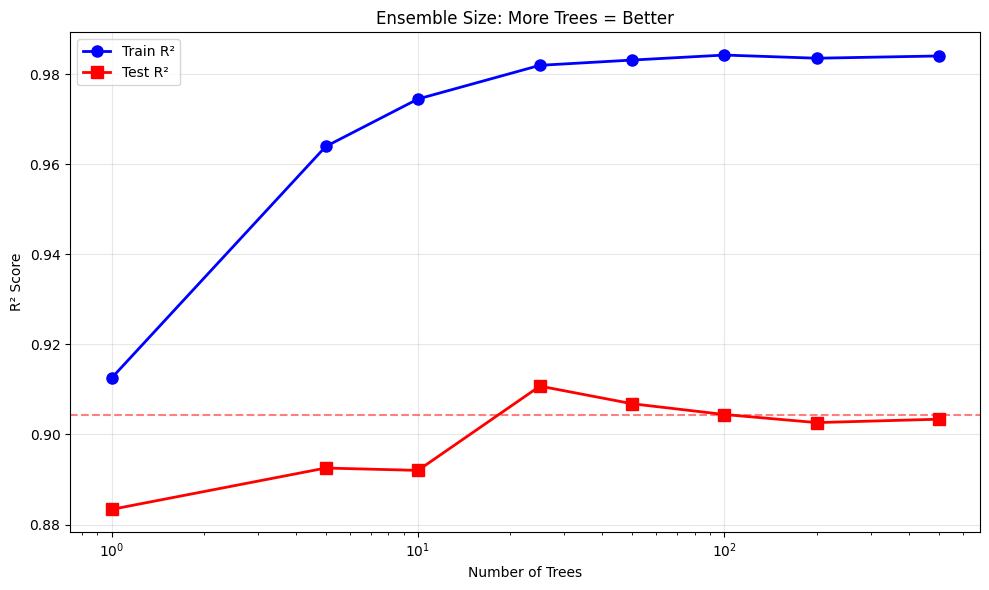

✅ More trees → better generalization
⚠️ But: Diminishing returns (100+ usually enough)
✓ Recommended: 100-200 trees


In [15]:
# Test different numbers of trees
n_trees = [1, 5, 10, 25, 50, 100, 200, 500]
train_scores = []
test_scores = []

for n in n_trees:
    rf = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_trees, train_scores, 'b-o', linewidth=2, markersize=8, label='Train R²')
plt.plot(n_trees, test_scores, 'r-s', linewidth=2, markersize=8, label='Test R²')
plt.xscale('log')
plt.xlabel('Number of Trees')
plt.ylabel('R² Score')
plt.title('Ensemble Size: More Trees = Better')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=forest_test_r2, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ More trees → better generalization")
print("⚠️ But: Diminishing returns (100+ usually enough)")
print(f"✓ Recommended: 100-200 trees")

---
## 4. How Bagging Works

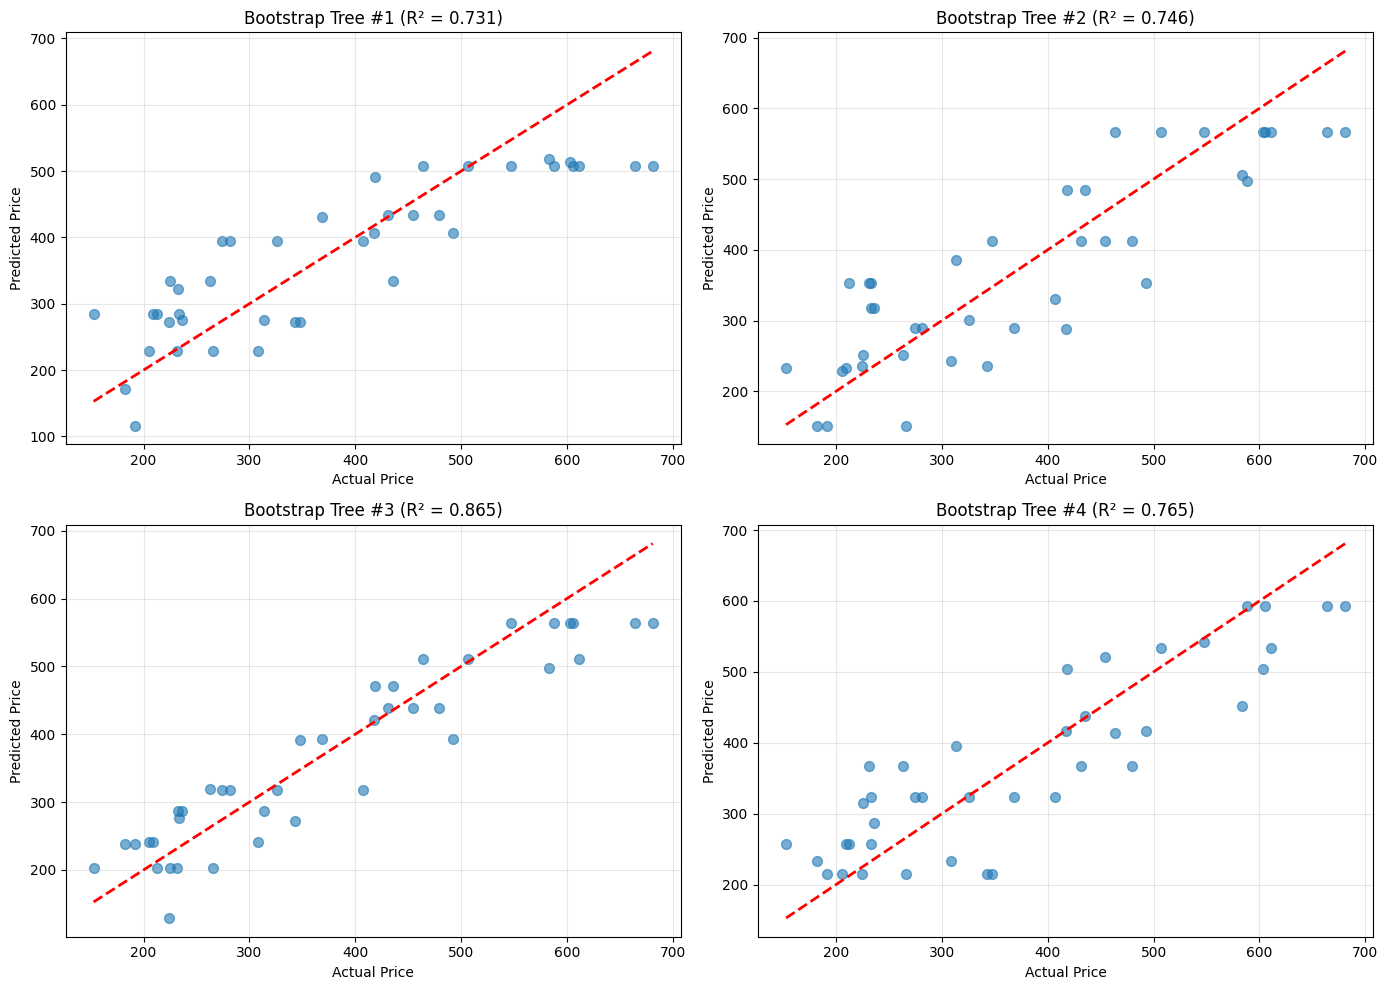

Bagging Process Explained:
1. Create N bootstrap samples (random with replacement)
2. Train separate tree on each sample
3. Each tree sees different data variations
4. Average predictions from all trees
5. Averaging reduces variance!


In [16]:
# Bagging (Bootstrap Aggregating) Visualization
# Show how different bootstrap samples create diverse trees

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Show bootstrap samples
np.random.seed(42)
n_bootstrap = 4
sample_size = len(X_train)

for idx in range(n_bootstrap):
    # Create bootstrap sample (sampling with replacement)
    bootstrap_indices = np.random.choice(sample_size, size=sample_size, replace=True)
    
    # Train tree on bootstrap sample
    tree_boot = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_boot.fit(X_train[bootstrap_indices], y_train[bootstrap_indices])
    
    # Make predictions
    y_pred_boot = tree_boot.predict(X_test)
    
    # Plot
    ax = axes[idx // 2, idx % 2]
    ax.scatter(y_test, y_pred_boot, alpha=0.6, s=50)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    
    boot_r2 = tree_boot.score(X_test, y_test)
    ax.set_title(f'Bootstrap Tree #{idx+1} (R² = {boot_r2:.3f})')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Bagging Process Explained:")
print("="*50)
print("1. Create N bootstrap samples (random with replacement)")
print(f"2. Train separate tree on each sample")
print("3. Each tree sees different data variations")
print("4. Average predictions from all trees")
print(f"5. Averaging reduces variance!")

---
## 5. Feature Importance

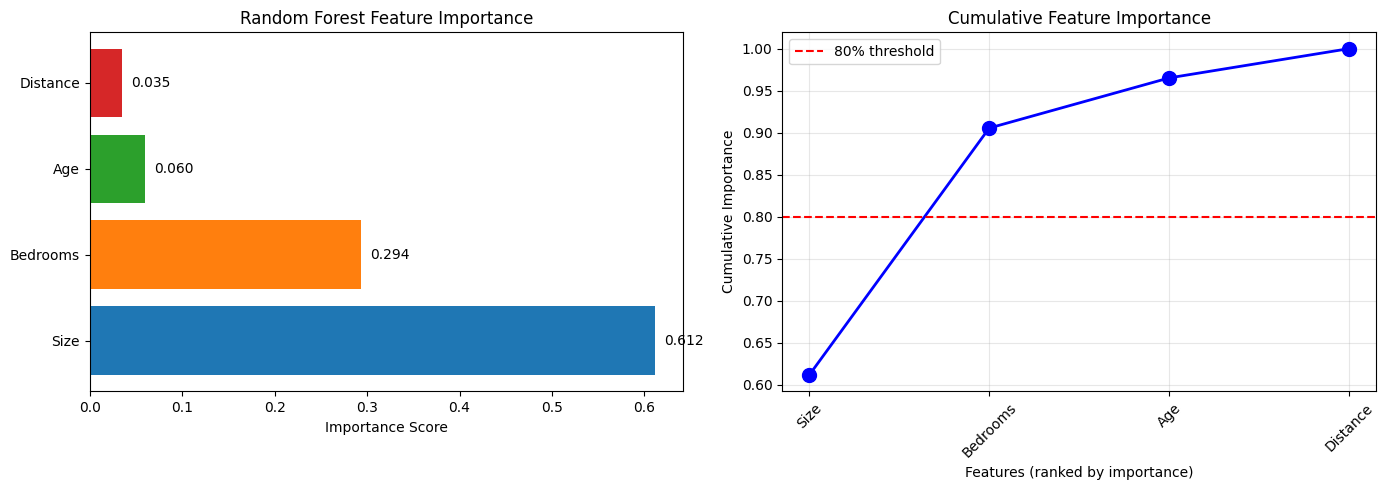

Feature Importance Ranking:
  1. Size: 0.6117
  2. Bedrooms: 0.2938
  3. Age: 0.0597
  4. Distance: 0.0348

💡 Size is most important (makes sense!)


In [17]:
# Get importance from forest
importance = forest.feature_importances_
feature_names = ['Size', 'Bedrooms', 'Age', 'Distance']

# Sort for plotting
sorted_idx = np.argsort(importance)[::-1]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].barh(
    np.array(feature_names)[sorted_idx],
    importance[sorted_idx],
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(importance)]
)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Random Forest Feature Importance')
for i, v in enumerate(importance[sorted_idx]):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Cumulative importance
cum_importance = np.cumsum(importance[sorted_idx])
axes[1].plot(range(len(feature_names)), cum_importance, 'bo-', linewidth=2, markersize=10)
axes[1].axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Features (ranked by importance)')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance')
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels(np.array(feature_names)[sorted_idx], rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank}. {feature_names[idx]}: {importance[idx]:.4f}")

print(f"\n💡 Size is most important (makes sense!)")

---
## 6. Out-of-Bag (OOB) Error

In [18]:
# OOB error: Free cross-validation
rf_oob = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    oob_score=True,  # Enable OOB
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

oob_score = rf_oob.oob_score_
test_score = rf_oob.score(X_test, y_test)

print("Out-of-Bag (OOB) Error:")
print("="*50)

print("\nHow it works:")
print("  - Each tree trained on ~63% of data (bootstrap)")
print("  - ~37% not used (out-of-bag)")
print("  - Evaluate each tree on its OOB samples")
print("  - Average OOB errors = OOB score")

print(f"\nResults:")
print(f"  OOB R²:  {oob_score:.4f}")
print(f"  Test R²: {test_score:.4f}")
print(f"  Close match? {abs(oob_score - test_score) < 0.05}")

print(f"\n✅ OOB ~= Test: Good estimate without separate validation set")

Out-of-Bag (OOB) Error:

How it works:
  - Each tree trained on ~63% of data (bootstrap)
  - ~37% not used (out-of-bag)
  - Evaluate each tree on its OOB samples
  - Average OOB errors = OOB score

Results:
  OOB R²:  0.8853
  Test R²: 0.9044
  Close match? True

✅ OOB ~= Test: Good estimate without separate validation set


---
## 7. Hyperparameter Tuning

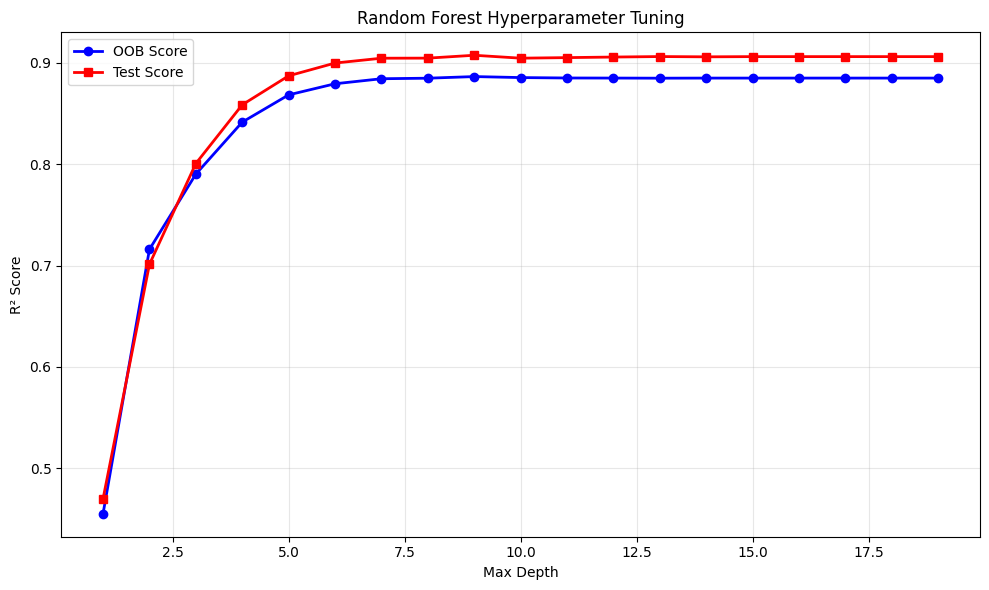

Optimal max_depth: 9


In [19]:
# Effects of max_depth on overfit
depths = range(1, 20)
oob_scores = []
test_scores = []

for depth in depths:
    rf = RandomForestRegressor(n_estimators=100, max_depth=depth, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    test_scores.append(rf.score(X_test, y_test))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, oob_scores, 'b-o', linewidth=2, label='OOB Score', markersize=6)
plt.plot(depths, test_scores, 'r-s', linewidth=2, label='Test Score', markersize=6)
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Random Forest Hyperparameter Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_scores)]
print(f"Optimal max_depth: {best_depth}")

---
## Key Takeaways

1. **Ensemble > Single model**: Average many ≠ mean of one
2. **Bagging**: Bootstrap samples → train different models
3. **Robust**: Better generalization than single tree
4. **Feature importance**: Which features matter most
5. **OOB error**: Free cross-validation estimate
6. **Hyperparameters**: n_estimators, max_depth, min_samples_leaf
7. **Parallelization**: n_jobs=-1 for speed

One of the best off-the-shelf algorithms!

---
## Your Turn

1. Load dataset with 4+ features
2. Train single tree vs random forest
3. Compare train/test R²
4. Tune n_estimators (1-500)
5. Extract feature importance
6. Compare OOB score vs test score